# Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import adi

# Plotting Functions

In [2]:
def plot_scatter(signal):
    plt.figure(figsize=(3, 3))
    plt.scatter(signal.real, signal.imag, color='blue', alpha=0.5, s=30)
    plt.xlabel("Real Part")
    plt.ylabel("Imaginary Part")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

def plot_signal(signal, length, label_name):
    plt.figure(figsize=(15, 3))
    plt.plot(signal[:length], '.-', label = label_name)
    # plt.grid(True)
    plt.legend()
    plt.show()


def smooth_psd_fft(rx_signal, fs, nperseg=1024):
    N = len(rx_signal)
    step = nperseg // 2  # 50% overlap
    psd_avg = np.zeros(nperseg)
    count = 0
    for i in range(0, N - nperseg, step):
        segment = rx_signal[i:i+nperseg]
        spectrum = np.fft.fftshift(np.fft.fft(segment, nperseg))
        psd = np.abs(spectrum)**2 / nperseg
        psd_avg += psd
        count += 1
    psd_avg /= count
    freq = np.fft.fftshift(np.fft.fftfreq(nperseg, 1/fs))
    freq, psd_smooth =  freq, psd_avg
    plt.figure(figsize=(4, 3))
    plt.plot(freq/1e6, 10*np.log10(psd_smooth))
    plt.title("Smoothed PSD (FFT averaging)")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Power (dB)")
    plt.grid(True)
    plt.show()

# Source Coding

### Text to ASCII, ASCII to binary


In [3]:
def text_to_bin(text):
    temp_bin_str = ''.join(format(ord(c), '07b') for c in text)
    bin_data = np.array([int(bit) for bit in temp_bin_str], dtype=int)
    return bin_data

text = 'Digital Communication and Coding Theory.'
print('number of characters: ', len(text))

message_bits = text_to_bin(text)
print('\nmessage bits length =', len(message_bits), '\n', message_bits)

number of characters:  40

message bits length = 280 
 [1 0 0 0 1 0 0 1 1 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0 1 1
 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 0 1
 1 0 1 1 1 0 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 1 1 0 1 0 0 1 1 1 0 0 0 1
 1 1 1 0 0 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0
 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0
 0 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1 0 0 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 0 0 1
 1 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 0 0 1 1 0 0 1 0 1 1 1 0 1 1 1 1
 1 1 1 0 0 1 0 1 1 1 1 0 0 1 0 1 0 1 1 1 0]


# Channel Coding

# Modulation - BPSK

In [4]:

bpsk_symbols = np.array([-1 if bit == 0 else 1 for bit in message_bits])


# Preamble Sequence - Barker

length og barker appended bpsk 293
[ 1  1  1  1  1 -1 -1  1  1 -1  1 -1  1  1 -1 -1 -1  1 -1 -1  1  1 -1  1
 -1 -1  1  1  1 -1 -1  1  1  1  1  1 -1  1 -1 -1  1  1  1  1 -1  1 -1 -1
  1  1 -1 -1 -1 -1  1  1  1 -1  1  1 -1 -1 -1  1 -1 -1 -1 -1 -1  1 -1 -1
 -1 -1  1  1  1  1 -1  1  1  1  1  1  1 -1  1  1 -1  1  1  1 -1  1  1 -1
  1  1  1  1 -1  1 -1  1  1  1 -1  1  1  1 -1  1  1 -1  1 -1 -1  1  1  1
 -1 -1 -1  1  1  1  1 -1 -1 -1 -1  1  1  1  1 -1  1 -1 -1  1  1 -1  1 -1
 -1  1  1  1 -1  1  1  1  1  1  1 -1  1  1  1 -1 -1  1 -1 -1 -1 -1 -1  1
  1 -1 -1 -1 -1  1  1  1 -1  1  1  1 -1  1  1 -1 -1  1 -1 -1 -1  1 -1 -1
 -1 -1 -1  1 -1 -1 -1 -1  1  1  1  1 -1  1  1  1  1  1  1 -1 -1  1 -1 -1
  1  1 -1  1 -1 -1  1  1  1 -1  1  1  1 -1  1  1 -1 -1  1  1  1 -1  1 -1
 -1 -1 -1 -1  1 -1  1 -1  1 -1 -1  1  1 -1  1 -1 -1 -1  1  1 -1 -1  1 -1
  1  1  1 -1  1  1  1  1  1  1  1 -1 -1  1 -1  1  1  1  1 -1 -1  1 -1  1
 -1  1  1  1 -1]


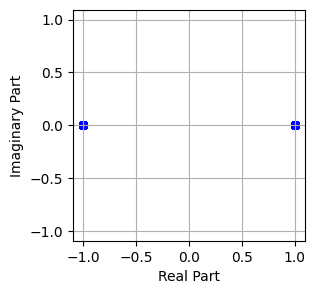

In [5]:
barker_code = np.array([1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1])
barker_appended_bpsk = np.concatenate((barker_code,  bpsk_symbols))

print('length og barker appended bpsk', len(barker_appended_bpsk))
print(barker_appended_bpsk)
################################
plot_scatter(barker_appended_bpsk)

### Zero Padded Sequence

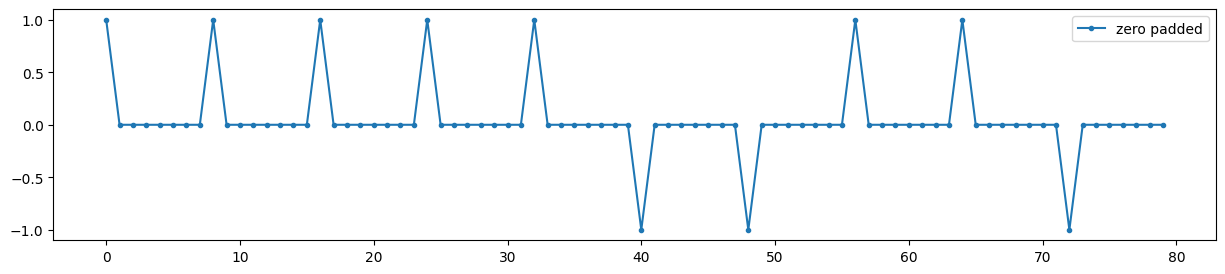

In [6]:
sps = 8
zero_padded = np.zeros(len(barker_appended_bpsk) * sps)
zero_padded[::sps] = barker_appended_bpsk

plot_signal(zero_padded.real, 80, 'zero padded')

# Pulse Shaping 

### Basic  - Square Pulse

In [7]:
# sps = 8
# square_pulse = np.ones(sps)

### Improvement
## Raised-Cosine Pulse

mid point 50


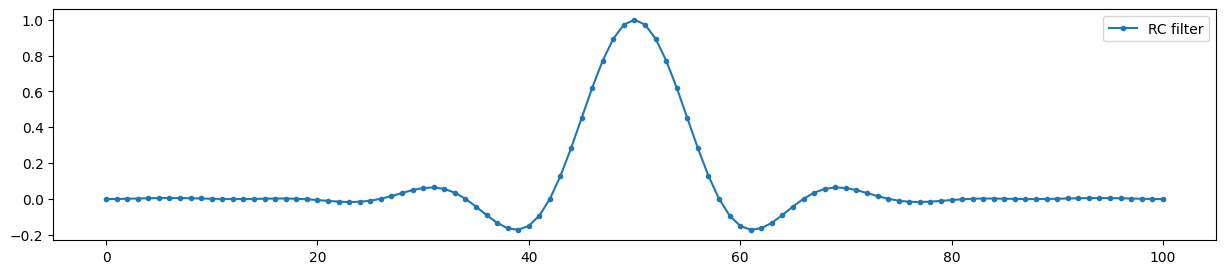

In [8]:
num_taps = 101
beta = 0.34
Ts = sps
t = np.arange(num_taps) - (num_taps-1)//2
rc_pulse = np.sinc(t/Ts) * np.cos(np.pi*beta*t/Ts) / (1 - (2*beta*t/Ts)**2)

print('mid point', num_taps//2)

plot_signal(rc_pulse, 200, 'RC filter')

### Pulse Shaping

length of pulse_shaped 2343


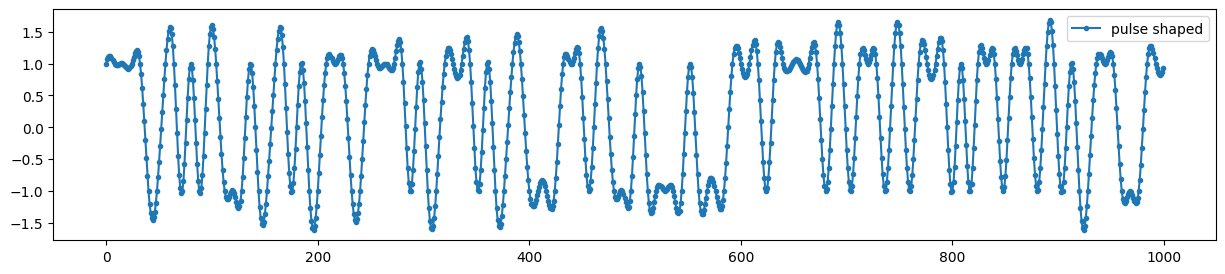

In [9]:
ps_conv_output = np.convolve(zero_padded, rc_pulse, mode = 'full')

pulse_shaped = ps_conv_output[num_taps//2: -1-num_taps//2]

print('length of pulse_shaped', len(pulse_shaped))

plot_signal(pulse_shaped.real, 1000, 'pulse shaped') # Plotting first 1000 samples


### Plot Spectrum

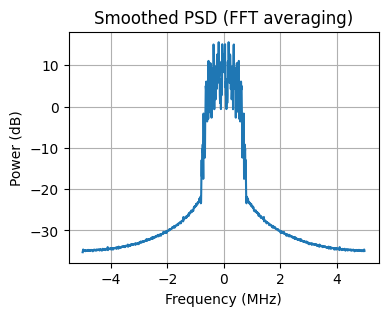

In [10]:
fs = 10e6
smooth_psd_fft(pulse_shaped, fs)

### Scaling

In [11]:
tx_signal = pulse_shaped * (2**14)

# Configure SDR and Transmit

In [12]:
sample_rate = 10e6 # Hz
carrier_freq = 985e6 # Hz
num_samps = 100000 

sdr = adi.Pluto("ip:192.168.2.1")
sdr.sample_rate = int(sample_rate)

sdr.tx_rf_bandwidth = int(sample_rate) 
sdr.tx_lo = int(carrier_freq)
sdr.tx_hardwaregain_chan0 = -15

sdr.tx_cyclic_buffer = True  
sdr.tx(tx_signal)  

In [13]:
# sdr.tx_destroy_buffer()